# Sarcasm Detection Models and Evaluation

Goal:
Train and evaluate multiple models for binary sarcasm detection in Albanian news text using the final balanced dataset created in `03c_merge_and_rebalance_dataset.ipynb`.

The task is defined as:
- `1` = sarcastic text
- `0` = non-sarcastic text

This notebook follows the same evaluation idea used in the category detection workflow: first establish classical baseline models, then compare them with a contextual transformer-based model.

Output:
A final model comparison table with accuracy, macro precision, macro recall, and macro F1-score.


### Workflow Overview

The notebook follows these steps:

1. Load the final balanced sarcasm dataset from `data/preprocessed_kosovo_news_with_is_sarcasm.csv`.
2. Verify that the dataset contains an equal number of sarcastic and non-sarcastic examples.
3. Train classical TF-IDF baseline models with **stratified K-fold cross-validation**: Multinomial Naive Bayes, Linear SVM, and Logistic Regression.
4. Fine-tune a multilingual transformer model with the same K-fold protocol for contextual sarcasm detection.
5. Summarize all model results in a shared leaderboard, reporting each metric as **mean ± standard deviation across the folds**.

The main comparison metric is macro F1-score, because it gives equal importance to both classes and balances precision with recall. Cross-validation makes the comparison more reliable than a single train/test split, since every example is used for evaluation exactly once and the fold-to-fold variance is reported.

### Libraries

This cell imports the libraries required for data loading, TF-IDF feature extraction, classical machine learning models, transformer fine-tuning, and evaluation.

A fixed seed is used to keep sampling and train/test splits reproducible across notebook runs. The MPS memory setting is included for local Apple Silicon execution.


In [1]:
# Used Libraries
import os
import sys
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from datasets import Dataset
from sklearn.svm import LinearSVC
from torch.nn import CrossEntropyLoss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)


PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from scripts.leaderboard import show_leaderboard

set_seed(42)
load_dotenv()

/Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

This step resolves the repository root and defines the input dataset used in the modeling experiments. The file is produced by `03c_merge_and_rebalance_dataset.ipynb`, so the modeling notebook can be rerun after rebuilding the balanced dataset.

`MODEL_COMPARISONS` stores the metrics produced by each model so that the final results table can be generated consistently.


In [2]:
BASE_DIR = Path.cwd().resolve()
while BASE_DIR != BASE_DIR.parent and not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
# Created by 03c_merge_and_rebalance_dataset.ipynb
DF = DATA_DIR / "preprocessed_kosovo_news_with_is_sarcasm.csv"
DATASET_NAME = "Balanced sarcasm dataset"

# Number of folds used for stratified K-fold cross-validation.
# Every model is evaluated with the same K_FOLDS and the same RANDOM_STATE so
# the folds are identical across models and the comparison stays fair.
K_FOLDS = 5
RANDOM_STATE = 42

MODEL_COMPARISONS = []
MODEL_ARTIFACTS = {}

### Read dataset

The balanced sarcasm dataset is loaded for inspection. The expected columns are `content`, `category`, and `is_sarcasm`, with optional source-tracking columns such as `source` or `source_dataset`.

The preview confirms that the text and labels are available before the training pipeline starts.


In [3]:
df = pd.read_csv(DF)
df.head()

,content,category,is_sarcasm,source,source_dataset
0,Deputetja nga radhët e Partisë Demokratike të ...,Lajme,1,GazetaExpress,kosovo_news_labeled_v1
1,Kryeministri Rama ka qenë në Shkodër për proçe...,Ballina;Shqiperi,1,GazetaExpress,kosovo_news_labeled_v1
2,Po zhvillohet në Itali faza e parë e eksperime...,Lajme,0,GazetaExpress,kosovo_news_labeled_v1
3,Shumë fansa e kanë përgëzuar Rina Balajn për “...,Rozë,1,GazetaExpress,kosovo_news_labeled_v1
4,shprehurit artistik. Ajo që e forcon konceptin...,sarcasm_flossk_historic_bootstrap,1,sarcasm_flossk_historic_bootstrap,sarcasm_flossk_historic_bootstrap


### Class Balance Check

The dataset should already be balanced by `03c_merge_and_rebalance_dataset.ipynb`. This check confirms the number of sarcastic and non-sarcastic examples before any model is trained.

The resulting `balanced_df` variable is reused across the baseline and transformer sections to keep the experiments comparable.


In [4]:
# ---------------------------
# CONFIRM / KEEP 50-50 BALANCED DATASET FROM 03c
# ---------------------------

sarcasm_df = df[df["is_sarcasm"] == 1]
non_sarcasm_df = df[df["is_sarcasm"] == 0]

print("Sarcasm rows:", len(sarcasm_df))
print("Non sarcasm rows:", len(non_sarcasm_df))

TARGET = len(sarcasm_df)

sarcasm_sample = sarcasm_df.sample(
    n=min(TARGET, len(sarcasm_df)),
    random_state=42
)

non_sarcasm_sample = non_sarcasm_df.sample(
    n=min(TARGET, len(non_sarcasm_df)),
    random_state=42
)

balanced_df = pd.concat(
    [sarcasm_sample, non_sarcasm_sample],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset:")
print(balanced_df["is_sarcasm"].value_counts())

df = balanced_df

Sarcasm rows: 1366
Non sarcasm rows: 1366

Balanced dataset:
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64


### Evaluation Helpers

These helper functions collect each model's evaluation metrics in the same schema used by `scripts.leaderboard.show_leaderboard`. This keeps the final results table consistent with `01_category_detection.ipynb`.

The leaderboard expects a dataset name, model name, metric means, and metric standard deviations. Because every model is evaluated with **stratified K-fold cross-validation**, `save_cv_results` receives the per-fold metric lists and stores the **mean and standard deviation across folds**. The standard deviation columns therefore describe how stable each metric is from fold to fold.

For the confusion matrix and error analysis, the helper also stores the **out-of-fold predictions** — the prediction made for each example on the single fold where it was held out — so the confusion matrix is computed once over the entire dataset rather than over a single 20% test split.

In [5]:
def save_results(
    model_name,
    acc,
    precision,
    recall,
    f1,
    dataset_name=DATASET_NAME,
    y_true=None,
    y_pred=None,
    class_labels=None,
):
    """Store metrics from a single train/test split (std = 0.0).

    Kept for backward compatibility. The cross-validated experiments in this
    notebook use ``save_cv_results`` instead.
    """
    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy_mean": float(acc),
        "accuracy_std": 0.0,
        "precision_mean": float(precision),
        "precision_std": 0.0,
        "recall_mean": float(recall),
        "recall_std": 0.0,
        "f1_mean": float(f1),
        "f1_std": 0.0,
    }
    return _store_and_display(row, model_name, y_true, y_pred, class_labels)


def save_cv_results(
    model_name,
    accs,
    precisions,
    recalls,
    f1s,
    dataset_name=DATASET_NAME,
    y_true=None,
    y_pred=None,
    class_labels=None,
):
    """Store metrics aggregated over K folds as mean ± standard deviation.

    Parameters
    ----------
    accs, precisions, recalls, f1s : list[float]
        One value per fold for each macro metric.
    y_true, y_pred : array-like, optional
        Concatenated out-of-fold ground truth / predictions over all folds,
        used for the aggregated confusion matrix in the error analysis section.
    """
    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "precision_mean": float(np.mean(precisions)),
        "precision_std": float(np.std(precisions)),
        "recall_mean": float(np.mean(recalls)),
        "recall_std": float(np.std(recalls)),
        "f1_mean": float(np.mean(f1s)),
        "f1_std": float(np.std(f1s)),
    }
    return _store_and_display(row, model_name, y_true, y_pred, class_labels)


def _store_and_display(row, model_name, y_true, y_pred, class_labels):
    MODEL_COMPARISONS.append(row)

    if y_true is not None and y_pred is not None:
        MODEL_ARTIFACTS[model_name] = {
            "y_true": np.asarray(y_true),
            "y_pred": np.asarray(y_pred),
            "class_labels": class_labels or ["Non-sarcastic", "Sarcastic"],
        }

    metric_cols = [
        "accuracy_mean", "accuracy_std",
        "precision_mean", "precision_std",
        "recall_mean", "recall_std",
        "f1_mean", "f1_std",
    ]

    display(
        pd.DataFrame([row]).style.format({col: "{:.4f}" for col in metric_cols})
    )

    return row


def plot_binary_confusion_matrix(y_true, y_pred, class_labels=None, title="Confusion Matrix"):
    class_labels = class_labels or ["Non-sarcastic", "Sarcastic"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(7.2, 5.8))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, fontsize=11)
    ax.set_yticklabels(class_labels, fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11, fontweight="bold")
    ax.set_ylabel("True label", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            pct = cm_norm[i, j] * 100
            color = "white" if cm_norm[i, j] >= 0.5 else "#0f172a"
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n{pct:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=11,
                fontweight="bold",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Row-normalized recall", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xticks(np.arange(-0.5, len(class_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(class_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    plt.show()


def show_best_model_confusion_matrix():
    if not MODEL_COMPARISONS:
        print("No model results available yet.")
        return

    best_row = max(MODEL_COMPARISONS, key=lambda row: row["f1_mean"])
    best_model_name = best_row["model"]
    artifact = MODEL_ARTIFACTS.get(best_model_name)

    if artifact is None:
        print(f"No stored predictions found for best model: {best_model_name}")
        return

    print(
        f"Best model by macro F1: {best_model_name} "
        f"(F1={best_row['f1_mean']:.4f}, Accuracy={best_row['accuracy_mean']:.4f})"
    )
    plot_binary_confusion_matrix(
        artifact["y_true"],
        artifact["y_pred"],
        class_labels=artifact["class_labels"],
        title=f"{best_model_name} | Out-of-fold Confusion Matrix",
    )

## Baseline models and results

In this section, we evaluate classical machine learning models for sarcasm detection. All baseline models use the same TF-IDF text representation and the same **stratified K-fold cross-validation** splits, so the comparison reflects the classifier choice rather than a difference in data or features.

The TF-IDF vectorizer is fitted **inside each fold** on the training portion only, which avoids leaking test-fold vocabulary into the feature space. Each model reports macro metrics as mean ± standard deviation across the folds.

### Multinomial Naive Bayes

Multinomial Naive Bayes is a lightweight probabilistic baseline commonly used for text classification. It works with word-frequency based representations and is useful for checking how much sarcasm signal can be captured from lexical patterns alone.

In this experiment, the model is trained on TF-IDF unigram and bigram features and evaluated with the same macro metrics used throughout the notebook.


In [9]:
# ================================================
# Naive Bayes Sarcasm Detection
# Stratified {}-fold cross-validation
# ================================================

if "balanced_df" not in globals():
    raise ValueError("balanced_df not found. Run preprocessing first.")

df = balanced_df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()
df["is_sarcasm"] = df["is_sarcasm"].astype(int)

print("Dataset size:", len(df))
print(df["is_sarcasm"].value_counts())

X = df["content"].to_numpy()
y = df["is_sarcasm"].to_numpy()

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_acc, fold_precision, fold_recall, fold_f1 = [], [], [], []
oof_true, oof_pred = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_text, X_test_text = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit the vectorizer on the training fold only (no test-fold leakage).
    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
    )
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = MultinomialNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)

    oof_true.extend(y_test.tolist())
    oof_pred.extend(y_pred.tolist())

    print(f"Fold {fold}/{K_FOLDS} -> acc={acc:.4f}  macro-F1={f1:.4f}")

print("\n=== Cross-validated metrics (mean ± std over", K_FOLDS, "folds) ===")
print(f"Accuracy : {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall   : {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"Macro F1 : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")

print("\n=== Aggregated Out-of-Fold Confusion Matrix ===")
print(confusion_matrix(oof_true, oof_pred))

print("\n=== Aggregated Out-of-Fold Classification Report ===")
print(classification_report(oof_true, oof_pred))

row = save_cv_results(
    model_name="MultinomialNB",
    accs=fold_acc,
    precisions=fold_precision,
    recalls=fold_recall,
    f1s=fold_f1,
    y_true=oof_true,
    y_pred=oof_pred,
    class_labels=["Non-sarcastic", "Sarcastic"],
)

Dataset size: 2732
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64
Fold 1/5 -> acc=0.8044  macro-F1=0.8044
Fold 2/5 -> acc=0.8172  macro-F1=0.8172
Fold 3/5 -> acc=0.8223  macro-F1=0.8222
Fold 4/5 -> acc=0.8059  macro-F1=0.8059
Fold 5/5 -> acc=0.8168  macro-F1=0.8167

=== Cross-validated metrics (mean ± std over 5 folds) ===
Accuracy : 0.8133 ± 0.0070
Precision: 0.8137 ± 0.0073
Recall   : 0.8133 ± 0.0070
Macro F1 : 0.8133 ± 0.0070

=== Aggregated Out-of-Fold Confusion Matrix ===
[[1130  236]
 [ 274 1092]]

=== Aggregated Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1366
           1       0.82      0.80      0.81      1366

    accuracy                           0.81      2732
   macro avg       0.81      0.81      0.81      2732
weighted avg       0.81      0.81      0.81      2732



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,MultinomialNB,0.8133,0.0070,0.8137,0.0073,0.8133,0.0070,0.8133,0.0070


### Linear SVM (LinearSVC)

Linear SVM is a strong baseline for sparse text classification tasks. It learns a linear decision boundary over TF-IDF features and often performs well when the dataset contains many lexical and phrase-level indicators.

The TF-IDF vectorizer uses unigrams and bigrams, allowing the model to capture individual words as well as short expressions that may indicate irony, mockery, or contrast.


In [8]:
# ================================================
# SVM Sarcasm Detection
# Stratified {}-fold cross-validation
# ================================================

if "balanced_df" not in globals():
    raise ValueError("balanced_df not found. Run preprocessing first.")

df = balanced_df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()
df["is_sarcasm"] = df["is_sarcasm"].astype(int)

print("Dataset size:", len(df))
print(df["is_sarcasm"].value_counts())

X = df["content"].to_numpy()
y = df["is_sarcasm"].to_numpy()

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_acc, fold_precision, fold_recall, fold_f1 = [], [], [], []
oof_true, oof_pred = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_text, X_test_text = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit the vectorizer on the training fold only (no test-fold leakage).
    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
    )
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = LinearSVC()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)

    oof_true.extend(y_test.tolist())
    oof_pred.extend(y_pred.tolist())

    print(f"Fold {fold}/{K_FOLDS} -> acc={acc:.4f}  macro-F1={f1:.4f}")

print("\n=== Cross-validated metrics (mean ± std over", K_FOLDS, "folds) ===")
print(f"Accuracy : {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall   : {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"Macro F1 : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")

print("\n=== Aggregated Out-of-Fold Confusion Matrix ===")
print(confusion_matrix(oof_true, oof_pred))

print("\n=== Aggregated Out-of-Fold Classification Report ===")
print(classification_report(oof_true, oof_pred))

row = save_cv_results(
    model_name="SVM",
    accs=fold_acc,
    precisions=fold_precision,
    recalls=fold_recall,
    f1s=fold_f1,
    y_true=oof_true,
    y_pred=oof_pred,
    class_labels=["Non-sarcastic", "Sarcastic"],
)

Dataset size: 2732
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64
Fold 1/5 -> acc=0.8282  macro-F1=0.8280
Fold 2/5 -> acc=0.8373  macro-F1=0.8370
Fold 3/5 -> acc=0.8260  macro-F1=0.8254
Fold 4/5 -> acc=0.8260  macro-F1=0.8258
Fold 5/5 -> acc=0.8352  macro-F1=0.8351

=== Cross-validated metrics (mean ± std over 5 folds) ===
Accuracy : 0.8305 ± 0.0048
Precision: 0.8325 ± 0.0044
Recall   : 0.8305 ± 0.0047
Macro F1 : 0.8303 ± 0.0048

=== Aggregated Out-of-Fold Confusion Matrix ===
[[1185  181]
 [ 282 1084]]

=== Aggregated Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1366
           1       0.86      0.79      0.82      1366

    accuracy                           0.83      2732
   macro avg       0.83      0.83      0.83      2732
weighted avg       0.83      0.83      0.83      2732



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,SVM,0.8305,0.0048,0.8325,0.0044,0.8305,0.0047,0.8303,0.0048


### Logistic Regression

Logistic Regression is another linear baseline trained on the same TF-IDF representation. It provides a useful comparison to LinearSVC because both models use similar input features but optimize different learning objectives.

Like the other baselines, it is evaluated with stratified K-fold cross-validation, and the TF-IDF vectorizer is refitted on the training portion of each fold so the reported result reflects the classifier choice under an identical evaluation protocol.

In [7]:
# ================================================
# Logistic Regression Sarcasm Detection
# Stratified {}-fold cross-validation
# ================================================

if "balanced_df" not in globals():
    raise ValueError("balanced_df not found. Run preprocessing first.")

df = balanced_df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()
df["is_sarcasm"] = df["is_sarcasm"].astype(int)

print("Dataset size:", len(df))
print(df["is_sarcasm"].value_counts())

X = df["content"].to_numpy()
y = df["is_sarcasm"].to_numpy()

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_acc, fold_precision, fold_recall, fold_f1 = [], [], [], []
oof_true, oof_pred = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_text, X_test_text = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit the vectorizer on the training fold only (no test-fold leakage).
    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
    )
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)

    oof_true.extend(y_test.tolist())
    oof_pred.extend(y_pred.tolist())

    print(f"Fold {fold}/{K_FOLDS} -> acc={acc:.4f}  macro-F1={f1:.4f}")

print("\n=== Cross-validated metrics (mean ± std over", K_FOLDS, "folds) ===")
print(f"Accuracy : {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall   : {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"Macro F1 : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")

print("\n=== Aggregated Out-of-Fold Confusion Matrix ===")
print(confusion_matrix(oof_true, oof_pred))

print("\n=== Aggregated Out-of-Fold Classification Report ===")
print(classification_report(oof_true, oof_pred))

row = save_cv_results(
    model_name="LogisticRegression",
    accs=fold_acc,
    precisions=fold_precision,
    recalls=fold_recall,
    f1s=fold_f1,
    y_true=oof_true,
    y_pred=oof_pred,
    class_labels=["Non-sarcastic", "Sarcastic"],
)

Dataset size: 2732
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64
Fold 1/5 -> acc=0.8044  macro-F1=0.8037
Fold 2/5 -> acc=0.8172  macro-F1=0.8169
Fold 3/5 -> acc=0.8187  macro-F1=0.8180
Fold 4/5 -> acc=0.8168  macro-F1=0.8162
Fold 5/5 -> acc=0.8077  macro-F1=0.8069

=== Cross-validated metrics (mean ± std over 5 folds) ===
Accuracy : 0.8130 ± 0.0058
Precision: 0.8171 ± 0.0054
Recall   : 0.8130 ± 0.0057
Macro F1 : 0.8123 ± 0.0059

=== Aggregated Out-of-Fold Confusion Matrix ===
[[1188  178]
 [ 333 1033]]

=== Aggregated Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.87      0.82      1366
           1       0.85      0.76      0.80      1366

    accuracy                           0.81      2732
   macro avg       0.82      0.81      0.81      2732
weighted avg       0.82      0.81      0.81      2732



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,LogisticRegression,0.8130,0.0058,0.8171,0.0054,0.8130,0.0057,0.8123,0.0059


## Transformer models

To complement the TF-IDF baselines, this section fine-tunes a multilingual transformer model. Transformer models can capture contextual information beyond word frequency, which is important for sarcasm because the intended meaning may depend on contrast, tone, or broader sentence context.

The transformer is evaluated with the **same stratified K-fold protocol** as the baselines: a fresh model is fine-tuned from scratch on each training fold and evaluated on the held-out fold, and the metrics are reported as mean ± standard deviation across folds.

> **Runtime warning:** fine-tuning the transformer `K_FOLDS` times is computationally expensive. On local Apple Silicon with `BATCH_SIZE = 1` and several epochs, this cell can take a long time (potentially hours). Reduce `EPOCHS`, increase `BATCH_SIZE`, or lower `K_FOLDS` if you only need a quick check.

### DistilBERT multilingual

This experiment fine-tunes `distilbert-base-multilingual-cased` for binary sarcasm detection. The configuration uses a small batch size and gradient accumulation to reduce memory pressure on local hardware.

For each of the `K_FOLDS` folds a new model is initialized, fine-tuned on the training portion, and evaluated on the held-out portion. Per-fold accuracy, macro precision, macro recall, and macro F1-score are averaged into the comparison table, and the out-of-fold predictions are collected for the confusion matrix and saved to `data/sarcasm_balanced_predictions_v1.csv`.

In [6]:
# ============================================================
# BERT fine-tuning for Sarcasm Detection (Albanian)
# Stratified K-fold cross-validation
# ============================================================

# ------------------------------------------------
# DEVICE
# ------------------------------------------------
use_mps = torch.backends.mps.is_available()
use_cuda = torch.cuda.is_available()
device = "mps" if use_mps else ("cuda" if use_cuda else "cpu")
torch.set_float32_matmul_precision("high")

REPO_ROOT = Path.cwd()

while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"

OUT_DIR = REPO_ROOT / "models" / "sarcasm_bert_balanced_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_FILE = DATA_DIR / "sarcasm_balanced_predictions_v1.csv"

# ------------------------------------------------
# MODEL CONFIG (memory safe)
# ------------------------------------------------
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LEN = 128
BATCH_SIZE = 1
GRAD_ACC = 8
EPOCHS = 6
LR = 3e-5

# ------------------------------------------------
# EXPECT balanced_df
# ------------------------------------------------
if "balanced_df" not in globals():
    raise ValueError("balanced_df not defined")

df = balanced_df.copy()
df.columns = [c.strip().lower() for c in df.columns]

if "labels" not in df.columns:
    df["labels"] = df["is_sarcasm"]

df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()
df["labels"] = df["labels"].astype(int)
df = df.reset_index(drop=True)

print("\nBalanced rows:", len(df))
print(df["labels"].value_counts())

texts = df["content"].to_numpy()
labels = df["labels"].to_numpy()

# ------------------------------------------------
# TOKENIZER / COLLATOR / METRICS (shared across folds)
# ------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["content"],
        truncation=True,
        max_length=MAX_LEN,
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# ------------------------------------------------
# WEIGHTED TRAINER (class-weighted loss)
# ------------------------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(
            weight=torch.tensor([1.0, 2.0]).to(model.device)
        )
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss

# ------------------------------------------------
# STRATIFIED K-FOLD CROSS-VALIDATION
# ------------------------------------------------
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_acc, fold_precision, fold_recall, fold_f1 = [], [], [], []
oof_index, oof_true, oof_pred, oof_conf = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(texts, labels), start=1):
    print(f"\n========== Fold {fold}/{K_FOLDS} ==========")

    train_df = pd.DataFrame({
        "content": texts[train_idx],
        "labels": labels[train_idx],
    })
    test_df = pd.DataFrame({
        "content": texts[test_idx],
        "labels": labels[test_idx],
    })

    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

    train_ds = train_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    keep = {"input_ids", "attention_mask", "labels"}
    train_ds = train_ds.remove_columns(
        [c for c in train_ds.column_names if c not in keep]
    )
    test_ds = test_ds.remove_columns(
        [c for c in test_ds.column_names if c not in keep]
    )

    # Fresh model per fold so folds are independent.
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
    )
    model.to(device)

    args = TrainingArguments(
        output_dir=str(OUT_DIR / f"fold_{fold}"),
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=25,
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACC,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        report_to="none",
        fp16=False,
        dataloader_pin_memory=False,
        remove_unused_columns=False,
        optim="adamw_torch",
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    if device == "mps":
        torch.mps.empty_cache()

    trainer.train()

    pred_out = trainer.predict(test_ds)
    logits = pred_out.predictions
    y_true = pred_out.label_ids
    y_pred = np.argmax(logits, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    conf = probs.max(axis=1)

    oof_index.extend(test_idx.tolist())
    oof_true.extend(y_true.tolist())
    oof_pred.extend(y_pred.tolist())
    oof_conf.extend(conf.tolist())

    print(f"Fold {fold} -> acc={acc:.4f}  macro-F1={f1:.4f}")

    # Save the last fold's fine-tuned model as a representative artifact.
    if fold == K_FOLDS:
        trainer.save_model(str(OUT_DIR))
        tokenizer.save_pretrained(str(OUT_DIR))
        print("\nSaved last-fold model to:", OUT_DIR)

    # Free memory before the next fold.
    del trainer, model
    if device == "mps":
        torch.mps.empty_cache()

# ------------------------------------------------
# AGGREGATED RESULTS
# ------------------------------------------------
print("\n=== Cross-validated metrics (mean ± std over", K_FOLDS, "folds) ===")
print(f"Accuracy : {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall   : {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"Macro F1 : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")

print("\n=== Aggregated Out-of-Fold Confusion Matrix ===")
print(confusion_matrix(oof_true, oof_pred))

print("\n=== Aggregated Out-of-Fold Classification Report ===")
print(classification_report(oof_true, oof_pred, digits=4))

row = save_cv_results(
    model_name="DistilBERT",
    accs=fold_acc,
    precisions=fold_precision,
    recalls=fold_recall,
    f1s=fold_f1,
    y_true=oof_true,
    y_pred=oof_pred,
    class_labels=["Non-sarcastic", "Sarcastic"],
)

# ------------------------------------------------
# SAVE OUT-OF-FOLD PREDICTIONS (full dataset)
# ------------------------------------------------
pred_df = pd.DataFrame({
    "content": texts[oof_index],
    "labels": labels[oof_index],
    "pred_label": oof_pred,
    "confidence": oof_conf,
})
pred_df.to_csv(PRED_FILE, index=False)

print("Saved out-of-fold predictions to:", PRED_FILE)


Balanced rows: 2732
labels
1    1366
0    1366
Name: count, dtype: int64

========== Fold 1/5 ==========


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1923.15it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.363560,0.509835,0.758684,0.763782,0.758556,0.757451
2,3.415775,0.415306,0.795247,0.808120,0.795433,0.793156
3,2.027651,0.542616,0.797075,0.798215,0.797131,0.796901
4,2.124358,0.888174,0.771481,0.792349,0.771236,0.767221
5,1.907102,1.010515,0.787934,0.791457,0.787833,0.787251
6,1.037542,1.059541,0.804388,0.804872,0.804424,0.804322


Fold 1 -> acc=0.8044  macro-F1=0.8043

========== Fold 2/5 ==========


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1963.95it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Fold 5 -> acc=0.7857  macro-F1=0.7856


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.32s/it]



Saved last-fold model to: /Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/models/sarcasm_bert_balanced_v1

=== Cross-validated metrics (mean ± std over 5 folds) ===
Accuracy : 0.7972 ± 0.0074
Precision: 0.7986 ± 0.0081
Recall   : 0.7972 ± 0.0074
Macro F1 : 0.7970 ± 0.0073

=== Aggregated Out-of-Fold Confusion Matrix ===
[[1131  235]
 [ 319 1047]]

=== Aggregated Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

           0     0.7800    0.8280    0.8033      1366
           1     0.8167    0.7665    0.7908      1366

    accuracy                         0.7972      2732
   macro avg     0.7983    0.7972    0.7970      2732
weighted avg     0.7983    0.7972    0.7970      2732



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,DistilBERT,0.7972,0.0074,0.7986,0.0081,0.7972,0.0074,0.7970,0.0073


Saved out-of-fold predictions to: /Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/data/sarcasm_balanced_predictions_v1.csv


## Results summary

The table below is rendered with the shared `show_leaderboard` helper imported from `scripts.leaderboard`, matching the result-table format used in `01_category_detection.ipynb`.

The table is grouped by dataset and sorted by macro F1-score. Each metric is reported as the **mean across the K folds**, with its **standard deviation** in the adjacent `_std` column, so a model that is both accurate and stable across folds can be identified at a glance.

In [10]:
show_leaderboard()

## Error Analysis

To better understand where the strongest sarcasm model still makes mistakes, we visualize the confusion matrix for the best-performing model based on mean macro F1-score.

Because the experiments use K-fold cross-validation, the confusion matrix is built from the **out-of-fold predictions** — every example is counted once, using the prediction made on the fold where it was held out. Each cell shows both the raw number of examples and the row-normalized percentage.

Best model by macro F1: SVM (F1=0.8303, Accuracy=0.8305)


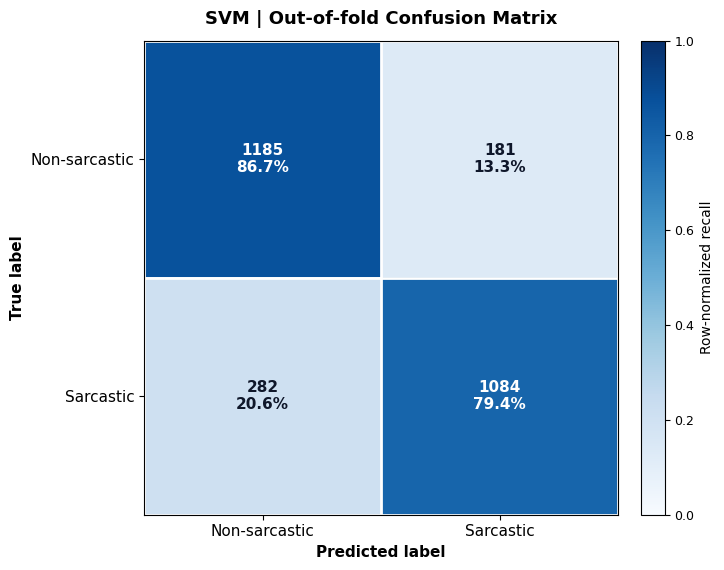

In [11]:
show_best_model_confusion_matrix()

The aggregated out-of-fold confusion matrix summarizes the best-performing model's behaviour over the **entire dataset** rather than a single 20% test split, so the counts reflect every example exactly once.

Reading the matrix, the diagonal cells show correctly classified non-sarcastic and sarcastic examples, while the off-diagonal cells show the two error types: non-sarcastic texts predicted as sarcastic (false positives) and sarcastic texts predicted as non-sarcastic (false negatives). In line with the per-fold metrics, the model is typically slightly stronger at recognizing non-sarcastic texts, since sarcasm in Albanian news language often depends on contextual cues that lexical and contextual features only partially capture.

Because the metrics are now cross-validated, the standard-deviation columns in the leaderboard indicate how consistent this behaviour is across folds: small standard deviations mean the confusion pattern shown here is stable rather than an artifact of one particular split.